**NAME : ABHIJITH P V**

**REGISTER NO : 24MSD7041**

**Image Classififcation Of Pandas and Bears using CNN**

In [58]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [11]:
#Defining batch_size , image dimensions and directory

batch_size=32
img_width=180
img_height=180
data_train='PandasBears/Train'
data_test='PandasBears/Test'

In [12]:
#Loading training dataset

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_train,
    validation_split=0.2,
    subset="training",
    seed=55,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 500 files belonging to 2 classes.
Using 400 files for training.


In [13]:
#Loading Validation dataset

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    data_train,
    validation_split=0.2,
    subset="validation",
    seed=55,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 500 files belonging to 2 classes.
Using 100 files for validation.


In [14]:
#Loading Testing Dataset

test_dataset = tf.keras.utils.image_dataset_from_directory(
    data_test,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 100 files belonging to 2 classes.


In [15]:
#Getting class names

class_names = train_dataset.class_names
print(f"Classes found: {class_names}")

Classes found: ['Bears', 'Pandas']


In [16]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.cache().prefetch(buffer_size=AUTOTUNE)

**Model Building CNN**

In [18]:
class_num = len(class_names)

In [19]:
model=Sequential([
    # --- Data Augmentation & Normalization ---
    layers.RandomFlip("horizontal",input_shape=(img_height,img_width,3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.Rescaling(1./255),

    # --- Convolutional Base ---
    layers.Conv2D(16,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.MaxPooling2D(),

    # --- Classifier Head ---
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(class_num,activation='softmax')
])

In [20]:
# Compiling the model

model.compile(optimizer='adam',
             loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
             metrics=['accuracy'])

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_zoom (RandomZoom)             │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 180, 180, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 180, 180, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 90, 90, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 90, 90, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 45, 45, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 45, 45, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 22, 22, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 30976)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,965,056 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,988,898 (15.22 MB)

 Trainable params: 3,988,898 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

**Model Training CNN**

In [23]:
epochs=15

history = model.fit(
    train_dataset,
    validation_data = validation_dataset,
    epochs=epochs
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - accuracy: 0.5564 - loss: 1.0257 - val_accuracy: 1.0000 - val_loss: 0.3089
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - accuracy: 0.9890 - loss: 0.2068 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9919 - loss: 0.0210 - val_accuracy: 0.9600 - val_loss: 0.1187
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 0.9910 - loss: 0.0741 - val_accuracy: 0.9300 - val_loss: 0.1506
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step - accuracy: 1.0000 - loss: 0.0166 - val_accuracy: 0.9900 - val_loss: 0.0395
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - accuracy: 0.9949 - loss: 0.0096 - val_accuracy: 1.0000 - val_loss: 0.0027
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 116ms/step - accuracy: 1.0000 - loss: 4.4913e-04 - val_accuracy: 0.9900 - val_loss: 0.0193
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy

**Model Evaluation CNN**

In [25]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

In [26]:
epochs_range = range(epochs)

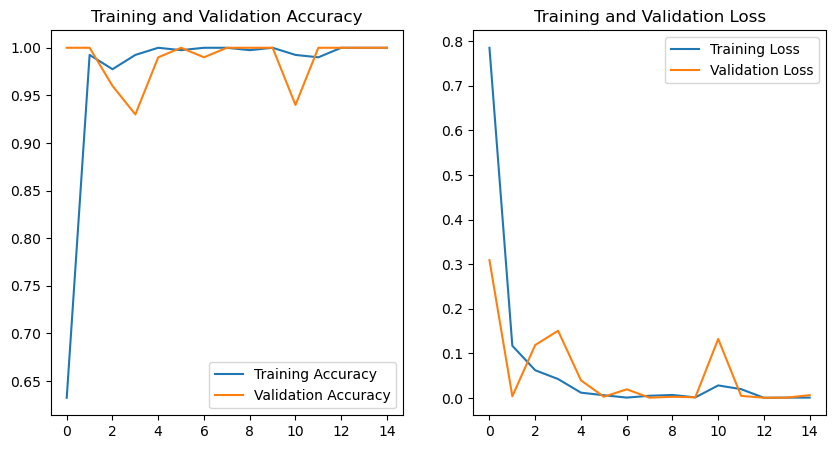

In [27]:
#Plotting the graph

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.plot(epochs_range,acc,label='Training Accuracy')
plt.plot(epochs_range,val_acc,label='Validation Accuracy')
plt.legend()
plt.title("Training and Validation Accuracy")

plt.subplot(1,2,2)
plt.plot(epochs_range,loss,label='Training Loss')
plt.plot(epochs_range,val_loss,label='Validation Loss')
plt.legend()
plt.title("Training and Validation Loss")
plt.show()

In [28]:
print("\n--- Evaluating on Test Data ---")
test_loss, test_acc = model.evaluate(test_dataset, verbose=2)
print(f"\nTest Accuracy: {test_acc:.4f}")


--- Evaluating on Test Data ---
4/4 - 0s - 47ms/step - accuracy: 1.0000 - loss: 1.0247e-04

Test Accuracy: 1.0000


In [29]:
true_labels = np.concatenate([y for x, y in test_dataset], axis=0)
predictions = model.predict(test_dataset)
predicted_labels = np.argmax(predictions, axis=1)
print(f"The class names are: {class_names}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
The class names are: ['Bears', 'Pandas']


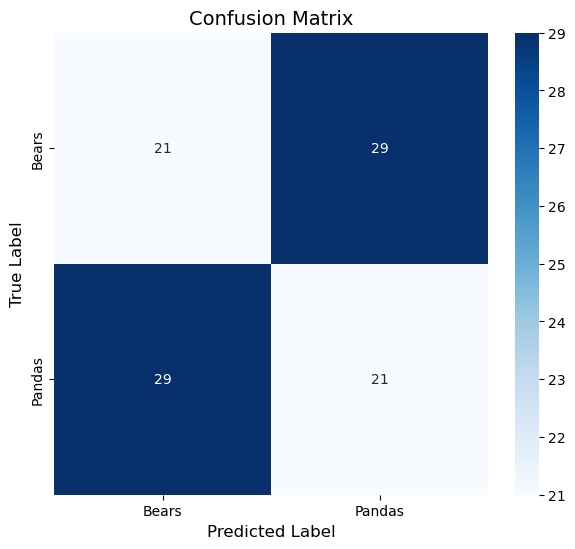

In [54]:
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix', fontsize=14)
plt.show()

In [60]:
print("Classification Report:\n", classification_report(true_labels,predicted_labels,target_names=class_names))

Classification Report:
               precision    recall  f1-score   support

       Bears       0.42      0.42      0.42        50
      Pandas       0.42      0.42      0.42        50

    accuracy                           0.42       100
   macro avg       0.42      0.42      0.42       100
weighted avg       0.42      0.42      0.42       100

